# Task 1 - Preattentive attributes and visual search

Data: `stimuli_search.csv` (90 trials, one row per item on screen).

In [1]:
%matplotlib inline

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

GREY = "#bbbbbb"
GREY_DARK = "#777777"
ACCENT = "#ee6677"
BLUE = "#4477aa"
INK = "#222222"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.edgecolor": GREY_DARK,
    "xtick.color": GREY_DARK,
    "ytick.color": GREY_DARK,
})


def declutter(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


def save(fig, name):
    fig.savefig(CHARTS / f"{name}.png", dpi=300, bbox_inches="tight")


# --- showing a stimulus in VS Code -------------------------------------
# VS Code delivers cell output and input() prompts on two separate
# channels, so without a pause the prompt box can open while the figure is
# still being painted - the reader would answer the previous picture.
# SETTLE is the head start the picture gets. The response timer starts
# after show_stimulus() returns, so this never lands inside rt_ms.
SETTLE = 0.35


def show_stimulus(fig, settle=SETTLE):
    clear_output(wait=True)   # old figure goes only when the new one lands
    display(fig)
    plt.close(fig)
    sys.stdout.flush()
    time.sleep(settle)

In [2]:
search = pd.read_csv(DATA / "stimuli_search.csv")
trials = search.drop_duplicates("trial")[["trial", "condition", "set_size", "target_present"]]
print(search.shape)
trials.groupby(["condition", "target_present"]).size().unstack()

(2430, 10)


target_present,no,yes
condition,,
colour,15,15
conjunction,15,15
shape,15,15


## 1. Rendering a trial

One function, draws a trial onto whatever `ax` it gets. No axes, ticks or title so nothing on screen competes with the items.

In [3]:
HUES = {"red": "#d62728", "blue": "#1f5fb4"}
MARKERS = {"circle": "o", "square": "s"}


def draw_trial(trial, ax, data=search):
    items = data[data["trial"] == trial]
    for (colour, shape), grp in items.groupby(["colour", "shape"]):
        ax.scatter(grp["x"], grp["y"], s=160, color=HUES[colour],
                   marker=MARKERS[shape], edgecolors="none")
    ax.set_xlim(0, 7)
    ax.set_ylim(0, 7)
    ax.set_aspect("equal")
    ax.axis("off")

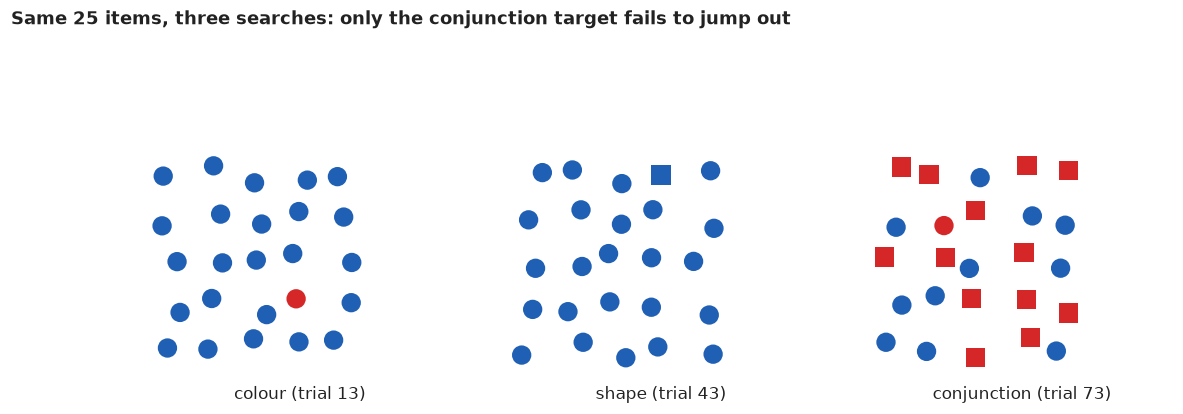

In [4]:
check = trials[(trials["set_size"] == 25) & (trials["target_present"] == "yes")].groupby("condition").head(1)
check = check.set_index("condition").loc[["colour", "shape", "conjunction"]]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.9))
for ax, (cond, row) in zip(axes, check.iterrows()):
    draw_trial(row["trial"], ax)
    ax.text(3.5, -0.4, f"{cond} (trial {row['trial']})", ha="center", va="top", fontsize=11)
fig.suptitle("Same 25 items, three searches: only the conjunction target fails to jump out",
             x=0.02, ha="left", fontweight="bold")
save(fig, "task1_three_conditions")
plt.show()

In the colour panel the red circle is the only red thing, so hue alone finds it. In the shape panel the square is the only square. In the conjunction panel there is red everywhere and circles everywhere, so nothing is unique on one feature and the eye has to check items one at a time.

## 2. Running it on a real person

Trial choice: one target-present and one target-absent trial per (condition x set size) cell, always the first repeat. The brief says 18 trials and also "two per cell". With 5 set sizes that is 30 trials, so I used 30 (about 3-4 minutes). To run exactly 18, set `SET_SIZES = [9, 25, 49]`.

How it works:
- trials are blocked by condition, the reader is told the target at the start of the block, never during
- order inside a block is shuffled
- the reader types `y` or `n` and Enter, `time.perf_counter()` measures from showing the display to the Enter key
- the time includes typing and the image showing up in Jupyter, so it is a constant offset on top of the real search time. The slope is what matters, and the offset doesn't change the slope.

Set `RUN_EXPERIMENT = True` only when the reader is sitting in front of the screen, then set it back to `False` so a re-run just loads `search_results.csv`.

In [5]:
SET_SIZES = [9, 16, 25, 36, 49]

chosen = (trials[trials["set_size"].isin(SET_SIZES)]
          .groupby(["condition", "set_size", "target_present"])
          .head(1)
          .reset_index(drop=True))
print(len(chosen), "trials selected")

TARGET_TEXT = {
    "colour": "a RED circle (everything else is blue circles)",
    "shape": "a blue SQUARE (everything else is blue circles)",
    "conjunction": "a RED CIRCLE (others are red squares and blue circles)",
}


def run_search_experiment(chosen, reader, seed=11):
    rng = np.random.default_rng(seed)
    rows = []
    for cond in ["colour", "shape", "conjunction"]:
        block = chosen[chosen["condition"] == cond].sample(frac=1, random_state=int(rng.integers(1e6)))
        # Instructions are printed, not passed to input(): VS Code's prompt
        # box is one short line and silently truncates anything longer.
        clear_output(wait=True)
        print(f"New block: {cond}")
        print(f"Target = {TARGET_TEXT[cond]}")
        print("Answer y if it is there, n if not, as fast as you can.")
        input("Enter to start... ")
        for _, t in block.iterrows():
            fig, ax = plt.subplots(figsize=(5.5, 5.5))
            draw_trial(t["trial"], ax)
            show_stimulus(fig)
            start = time.perf_counter()
            reprompted = False
            answer = input("present? y/n: ").strip().lower()
            while not answer.startswith(("y", "n")):
                reprompted = True
                answer = input("please type y or n: ").strip().lower()
            # timed to the first VALID y/n, so a stray keypress does not
            # hand this trial an artificially short rt
            rt = (time.perf_counter() - start) * 1000
            rows.append({
                "reader": reader,
                "trial": t["trial"],
                "condition": cond,
                "set_size": t["set_size"],
                "target_present": t["target_present"],
                "response": answer,
                "rt_ms": round(rt, 1),
                "reprompted": reprompted,
                "correct": answer.startswith("y") == (t["target_present"] == "yes"),
            })
    clear_output(wait=True)
    return pd.DataFrame(rows)

30 trials selected


In [6]:
RUN_EXPERIMENT = False
READER = "Sami (self-test)"
RESULTS_FILE = Path("search_results.csv")

if RUN_EXPERIMENT:
    if READER.startswith("write the reader"):
        raise ValueError("Set READER to your reader's first name before running.")
    results = run_search_experiment(chosen, READER)
    results.to_csv(RESULTS_FILE, index=False)
elif RESULTS_FILE.exists():
    results = pd.read_csv(RESULTS_FILE)
else:
    results = None
    print("search_results.csv not found yet. Set RUN_EXPERIMENT = True and run this cell with your reader.")

results

,reader,trial,condition,set_size,target_present,response,rt_ms,reprompted,correct
0,Sami (self-test),10,colour,16,no,y,126037.4,True,False
1,Sami (self-test),4,colour,9,no,y,121633.1,False,False
2,Sami (self-test),13,colour,25,yes,y,1828.8,False,True
3,Sami (self-test),28,colour,49,no,y,1310.9,False,False
4,Sami (self-test),25,colour,49,yes,y,1856.4,False,True
5,Sami (self-test),22,colour,36,no,y,1079.0,False,False
6,Sami (self-test),19,colour,36,yes,y,1252.6,False,True
7,Sami (self-test),16,colour,25,no,y,2203.0,False,False
8,Sami (self-test),7,colour,16,yes,y,810.6,False,True
9,Sami (self-test),1,colour,9,yes,y,2463.5,False,True


**Reader:** Sami (me), a self-test rather than a separate reader.
**When / where:** 3 October 2026, on my laptop screen, in VS Code.
**What I knew:** the target for each block, which was printed before it started. I tried to answer as fast as I could without guessing.

**Data:** `search_results.csv` is my only run (30 trials, one of which needed a re-prompt). Two problems with it:
- **The first trials of each block are very slow** because I was still working out the interface (waiting for the picture, finding the input box), not searching. Colour: 126.0 s and 121.6 s for its first two trials. Shape: 32.3 s and 13.7 s. Conjunction: 22.8 s for its first trial. Everything else took 0.8 to 5.5 s.
- **In the colour block I answered y on every trial by mistake**, so all five colour target-absent trials are wrong (colour target-absent accuracy is 0). The colour target-present trials are still correct.


## 3. Response time vs set size (target present only)

Absent trials are kept out of this chart because they are slower for a different reason (the reader has to convince themselves nothing is there). Wrong answers are dropped before fitting, and the count is printed.

In [7]:
if results is None:
    print("No results yet - run the experiment first.")
else:
    acc = results.pivot_table(index="condition", columns="target_present",
                              values="correct", aggfunc="mean").round(2)
    print("accuracy\n", acc, "\n")
    present = results[(results["target_present"] == "yes") & results["correct"]]
    absent = results[(results["target_present"] == "no") & results["correct"]]
    dropped = (results["target_present"] == "yes").sum() - len(present)
    print(f"present-trial errors dropped: {dropped}")
    if "reprompted" in results.columns:
        print(f"re-prompted trials (kept in): {int(results['reprompted'].sum())}")

    def slope_table(df):
        out = {}
        for cond, g in df.groupby("condition"):
            if g["set_size"].nunique() > 1:
                out[cond] = np.polyfit(g["set_size"], g["rt_ms"], 1)[0]
        return pd.Series(out, name="ms per item").round(1)

    slopes = pd.DataFrame({"present": slope_table(present), "absent": slope_table(absent)})
    display(slopes)

accuracy
 target_present   no  yes
condition               
colour          0.0  1.0
conjunction     1.0  1.0
shape           1.0  1.0 

present-trial errors dropped: 0
re-prompted trials (kept in): 1


,present,absent
colour,-4.7,NaN
conjunction,18.1,-137.1
shape,-296.4,1.9


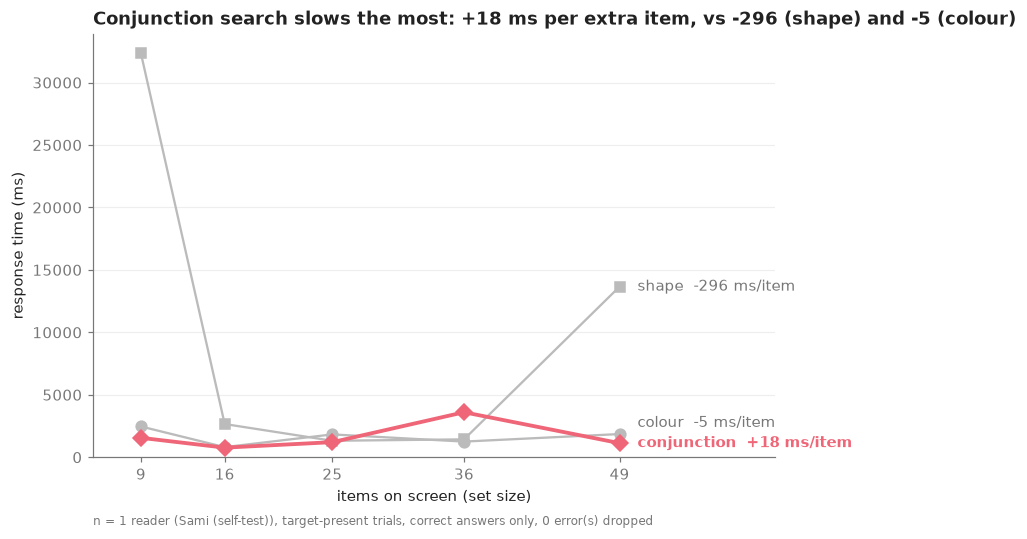

In [8]:
if results is not None:
    order = slopes["present"].sort_values()
    steep = order.index[-1]
    others = [c for c in order.index if c != steep]
    markers = {"colour": "o", "shape": "s", "conjunction": "D"}

    ends = present.sort_values("set_size").groupby("condition").last()
    label_y = ends["rt_ms"].sort_values().to_dict()
    gap = 0.05 * present["rt_ms"].max()
    prev = None
    for c in list(label_y):
        if prev is not None and label_y[c] - label_y[prev] < gap:
            label_y[c] = label_y[prev] + gap
        prev = c

    fig, ax = plt.subplots(figsize=(8, 5))
    for cond, g in present.groupby("condition"):
        g = g.sort_values("set_size")
        hit = cond == steep
        ax.plot(g["set_size"], g["rt_ms"], marker=markers[cond],
                color=ACCENT if hit else GREY, linewidth=2.5 if hit else 1.5,
                markersize=7, zorder=3 if hit else 2)
        ax.text(g["set_size"].iloc[-1] + 1.5, label_y[cond],
                f"{cond}  {slopes.loc[cond, 'present']:+.0f} ms/item",
                va="center", color=ACCENT if hit else GREY_DARK,
                fontweight="bold" if hit else "normal")

    ax.set_title(f"{steep.capitalize()} search slows the most: "
                 f"{slopes.loc[steep, 'present']:+.0f} ms per extra item, "
                 f"vs {slopes.loc[others[0], 'present']:+.0f} ({others[0]}) "
                 f"and {slopes.loc[others[1], 'present']:+.0f} ({others[1]})")
    ax.set_xlabel("items on screen (set size)")
    ax.set_ylabel("response time (ms)")
    ax.set_ylim(0, None)
    ax.set_xlim(5, 62)
    ax.set_xticks(SET_SIZES)
    ax.grid(axis="y", color="#eeeeee")
    ax.set_axisbelow(True)
    declutter(ax)
    ax.text(0, -0.16, f"n = 1 reader ({READER}), target-present trials, correct answers only, {dropped} error(s) dropped",
            transform=ax.transAxes, fontsize=8, color=GREY_DARK)
    save(fig, "task1_rt_vs_setsize")
    plt.show()

**What the eye does here.** Y-position carries response time, the channel people read most accurately for a number, and each condition is joined into a line so you follow three trends, not 15 dots.  
The one strong colour marks the steepest condition, which is what the title is about.  
The other two stay grey, told apart by marker shape and a direct label, so colour is not the only cue; the end labels use proximity instead of a legend.

## 4. Reading the slopes

Target-present trials, correct answers only. There were no present-trial errors, so nothing was dropped.

- colour: -4.7 ms/item
- shape: -296.4 ms/item
- conjunction: +18.1 ms/item

A slope near zero means adding distractors costs nothing, so the items are being checked in parallel. That is preattentive. A slope that clearly rises means each extra item adds time, so the reader is going through them one by one (serial search).

Expected: colour and shape flat, conjunction rising. What I got: colour came out flat, as expected. Conjunction rose a little (+18 ms/item), which is why the chart highlights it. Shape came out strongly negative, and that isn't a real effect. Its set-size-9 trial was the first trial of the block (32.3 s) and its set-size-49 trial was the second (13.7 s), both from while I was still working out the interface. With one trial per point, those two values decide the line. The other three shape trials took 1.3 to 2.7 s.

As a check (not in the chart), I dropped the first two trials of every block. Colour stays at -4.7 ms/item, shape becomes -58.7 and conjunction becomes -3.9. So the conjunction rise also depends on a single early trial (3.6 s at set size 36, the second trial of its block). Once the early trials are removed, none of the three conditions clearly rises, so this run doesn't show the serial-search pattern for conjunction.

The target-absent slopes are even weaker. Colour has none, because I answered y on every colour trial by mistake and all its absent trials are wrong. The conjunction absent slope (-137.1) is mostly the 22.8 s first trial of that block.

This is one person with one trial per point, and the start of every block was spent learning the interface, so it's a demonstration, not proof. A fair rerun would add a few practice trials before each block and repeat each set size several times.

I was also my own reader, on stimuli I generated myself, so I knew what each target looked like before the picture appeared. That bias works in favour of the easy conditions looking flat, and it is a further reason to treat this as a demonstration rather than a measurement.

## 5. Why "red" and "circle" are instant but "red and circle" isn't

Early vision builds separate maps for separate features, one for colour, one for shape, and so on, and it builds them across the whole screen at once. If the target is the only red item, the red map has one bright spot and attention goes straight there, no matter how many blue items there are. Same for the only square in the shape map.

In the conjunction displays the red map lights up at the target and at every red square, and the circle map lights up at the target and every blue circle. No single map has one unique spot. The only place the target is unique is where both maps overlap, and the visual system can't combine features "for free" across the whole display. Joining colour and shape for one object needs attention on that object, so the eye has to visit items one at a time. That's why time grows with set size (Treisman's feature integration idea).

**Where I did this to a reader without realising.** In Week 1 the scatter "Fare is driven by class, not by age" coloured points by class over age and fare. If someone wants "the 3rd class children", they need a colour (3rd class) and a position (left side, low age) together, which is a conjunction. They end up scanning points on the left one by one to check the colour. If that question mattered, I should have highlighted that group in one colour and greyed out everything else, so it becomes a single-feature search.